In [1]:
# Fix parameter initialization - remove trailing commas
spacing = 2  # not spacing=3,
num_sampled_points = 10000
smoothing = 0.1

# Smoothing parameters
time_sigma = 2.0    # Controls temporal smoothing
spatial_sigma = 1.0  # Controls spatial smoothing

In [2]:
import pandas as pd
import numpy as np
import pandas as pd
from scipy.interpolate import splprep, splev
from scipy.spatial.distance import euclidean
from tqdm.notebook import tqdm
from ipywidgets import interactive, fixed, IntSlider
import matplotlib.pyplot as plt

# Load the dataframes from CSV files
skeleton_x = pd.read_csv('skeleton_spline_X_coords.csv', header = None)
skeleton_y = pd.read_csv('skeleton_spline_Y_coords.csv', header = None)
spline_K = pd.read_csv('skeleton_spline_K.csv', header = None)

# Print basic information
print(f"Loaded skeleton_x DataFrame with shape: {skeleton_x.shape}")
print(f"Loaded skeleton_y DataFrame with shape: {skeleton_y.shape}")

# Display the first few rows of each dataframe
print("\nFirst 5 rows of skeleton_x:")
display(skeleton_x.head())

print("\nFirst 5 rows of skeleton_y:")
display(skeleton_y.head())

Loaded skeleton_x DataFrame with shape: (4919, 20)
Loaded skeleton_y DataFrame with shape: (4919, 20)

First 5 rows of skeleton_x:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,84.0,80.374,76.230,71.516,66.803,61.675,56.962,53.054,52.000,53.248,56.166,59.000,59.883,59.0,58.523,58.275,60.486,64.987,69.701,74.0
1,84.0,82.000,78.859,74.582,69.890,64.784,59.678,55.283,52.380,52.402,54.598,57.000,59.000,60.0,59.000,58.000,59.000,62.436,67.308,72.0
2,84.0,83.000,79.471,75.207,70.505,65.303,60.101,55.514,52.000,52.307,54.000,57.000,59.000,60.0,59.000,58.000,59.207,62.886,67.443,72.0
3,84.0,83.000,79.577,75.365,70.803,65.675,60.547,55.883,52.257,52.000,54.045,56.964,59.000,60.0,59.000,58.000,59.000,61.991,66.287,71.0
4,85.0,83.000,81.000,77.043,72.171,67.300,62.014,57.143,53.071,52.000,53.455,56.485,59.000,60.0,59.000,58.000,59.000,61.475,66.129,71.0



First 5 rows of skeleton_y:


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19
0,88.0,84.374,82.000,81.000,80.0,80.0,79.0,76.054,71.363,66.752,62.834,58.880,54.117,49.453,44.523,39.725,35.514,34.000,35.000,37.0
1,91.0,86.723,83.000,81.000,80.0,80.0,80.0,78.283,74.380,69.598,65.402,61.291,57.013,52.322,47.630,42.938,38.247,34.564,34.000,35.0
2,91.0,86.212,82.471,80.207,79.0,79.0,79.0,77.514,73.768,68.693,64.192,60.232,55.859,51.071,46.283,41.495,36.793,33.114,32.443,34.0
3,90.0,85.287,81.577,79.365,78.0,78.0,78.0,76.883,73.257,68.235,63.955,60.036,55.752,51.038,46.325,41.611,36.898,33.009,31.000,32.0
4,91.0,86.543,82.086,79.000,78.0,77.0,77.0,76.000,73.071,68.229,63.545,59.515,55.271,50.400,45.529,40.657,35.786,31.525,30.000,31.0


In [3]:
def fit_spline(x_coords, y_coords, smoothing):
    """
    Fits a B-spline to the given x and y coordinates.
    """
    if len(x_coords) < 3:
        return None
    tck, _ = splprep([x_coords, y_coords], s=smoothing)  # Fixed typo: x*coords -> x_coords
    return tck

def arc_length_resampling(tck, num_sampled_points, spacing):
    """
    Resamples spline at equal arc-length intervals.
    Returns resampled coordinates and total spline length.
    """
    u_fine = np.linspace(0, 1, num_sampled_points)
    fine_x, fine_y = splev(u_fine, tck)
    
    distances = np.sqrt(np.diff(fine_x) ** 2 + np.diff(fine_y) ** 2)
    cumulative_dist = np.insert(np.cumsum(distances), 0, 0)
    total_length = cumulative_dist[-1]  # Total length of the spline
    
    target_distances = np.arange(0, total_length, spacing)
    new_x = np.interp(target_distances, cumulative_dist, fine_x)
    new_y = np.interp(target_distances, cumulative_dist, fine_y)
    
    return list(new_x), list(new_y), total_length  # Added total_length to return values

def resample_skeleton(x_coords, y_coords, spacing=10, num_sampled_points=10000, smoothing=0.1):
    """
    Resamples skeleton using arc-length parameterization for even spacing.
    Returns resampled coordinates and spline length.
    """
    if len(x_coords) < 3:
        return [np.nan], [np.nan], np.nan
        
    tck = fit_spline(x_coords, y_coords, smoothing)
    if tck is None:
        return [np.nan], [np.nan], np.nan
        
    new_x, new_y, spline_length = arc_length_resampling(tck, num_sampled_points, spacing)
    return new_x, new_y, spline_length

def refine_skeleton_spacing(skel_x_df, skel_y_df, spacing=10, num_sampled_points=10000, smoothing=0.1):
    """
    Generates evenly spaced points along the skeleton for each frame using arc-length parameterization.
    Also returns spline lengths for each frame.
    """
    print(f"Processing {len(skel_x_df)} frames...")
    print(f"Parameters: spacing={spacing}, sampling_points={num_sampled_points}, smoothing={smoothing}")
    
    all_new_x = []
    all_new_y = []
    all_lengths = []  # Store lengths for all frames
    max_points = 0
    
    for frame in tqdm(range(len(skel_x_df))):
        x_coords = skel_x_df.iloc[frame].dropna().values
        y_coords = skel_y_df.iloc[frame].dropna().values
        
        new_x, new_y, spline_length = resample_skeleton(
            x_coords, y_coords,
            spacing=spacing,
            num_sampled_points=num_sampled_points,
            smoothing=smoothing
        )
        
        # Convert to list if numpy array
        if isinstance(new_x, np.ndarray):
            new_x = new_x.tolist()
        if isinstance(new_y, np.ndarray):
            new_y = new_y.tolist()
            
        max_points = max(max_points, len(new_x))
        all_new_x.append(new_x)
        all_new_y.append(new_y)
        all_lengths.append(spline_length)
    
    # Create lengths DataFrame
    lengths_df = pd.DataFrame(all_lengths, columns=['spline_length'])
    
    print("\nCreating final DataFrames...")
    # Ensure proper padding with lists
    padded_x = [x + [np.nan] * (max_points - len(x)) for x in all_new_x]
    padded_y = [y + [np.nan] * (max_points - len(y)) for y in all_new_y]
    
    new_cols = [f'point_{i+1}' for i in range(max_points)]
    
    new_x_df = pd.DataFrame(padded_x, columns=new_cols)
    new_y_df = pd.DataFrame(padded_y, columns=new_cols)
    
    # Print length statistics
    valid_lengths = [l for l in all_lengths if not np.isnan(l)]
    if valid_lengths:
        print(f"\nSpline Length Statistics:")
        print(f"Mean: {np.mean(valid_lengths):.2f} pixels")
        print(f"Min: {np.min(valid_lengths):.2f} pixels")
        print(f"Max: {np.max(valid_lengths):.2f} pixels")
        print(f"Std: {np.std(valid_lengths):.2f} pixels")
    
    print(f"Done! Maximum points in any frame: {max_points}")
    return new_x_df, new_y_df, lengths_df

new_x_df, new_y_df, lengths_df = refine_skeleton_spacing(skeleton_x, skeleton_y, spacing, num_sampled_points, smoothing)

Processing 4919 frames...
Parameters: spacing=2, sampling_points=10000, smoothing=0.1


  0%|          | 0/4919 [00:00<?, ?it/s]


Creating final DataFrames...

Spline Length Statistics:
Mean: 96.46 pixels
Min: 60.36 pixels
Max: 9025.30 pixels
Std: 130.87 pixels
Done! Maximum points in any frame: 4513


Original data points: 4919
After filtering outliers: 4671
Removed 248 outliers

Skeleton Length Statistics:
Mean: 96.46 ± 130.88 pixels
Median: 94.66 pixels
Range (99% of data): -296.19 to 489.11 pixels
5th percentile: 89.02 pixels
95th percentile: 98.15 pixels


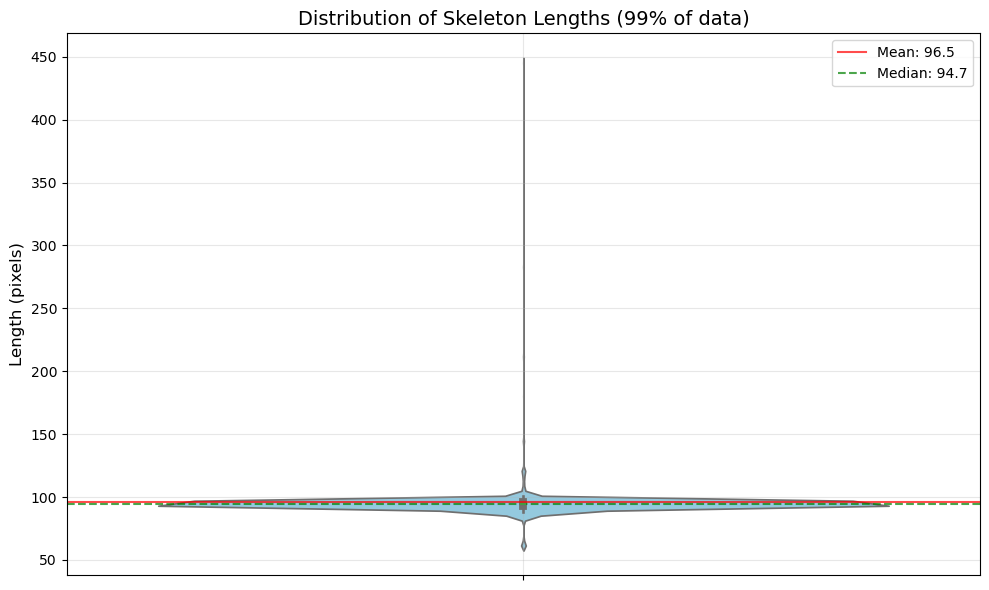

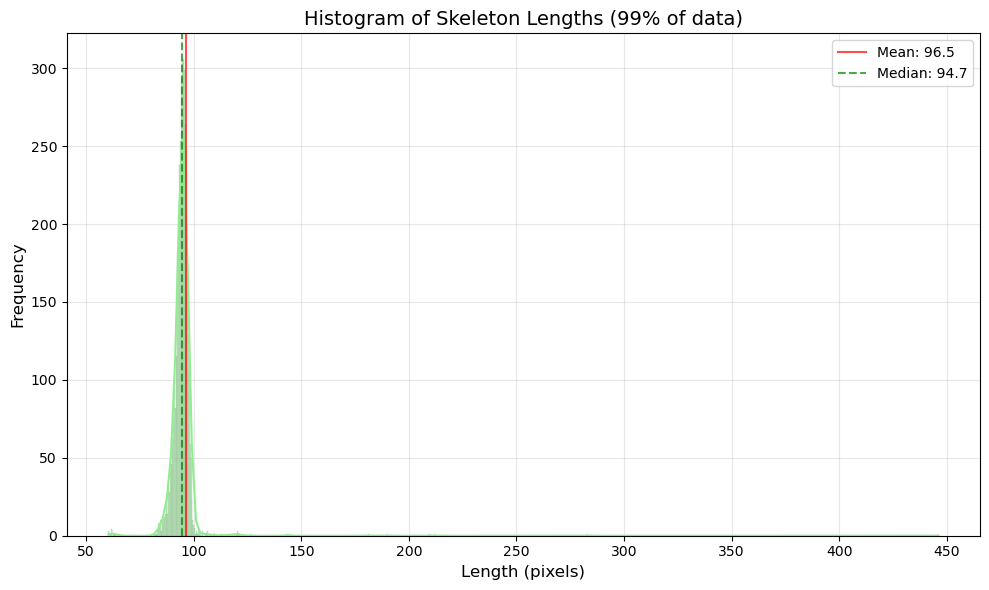

In [4]:
# Import necessary libraries
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Calculate statistics
mean_length = lengths_df['spline_length'].mean()
std_length = lengths_df['spline_length'].std()
median_length = lengths_df['spline_length'].median()

# Filter extreme outliers (keeping 99% of data within 3 standard deviations)
lower_bound = mean_length - 3 * std_length
upper_bound = mean_length + 3 * std_length
filtered_lengths = lengths_df[(lengths_df['spline_length'] >= lower_bound) & 
                             (lengths_df['spline_length'] <= upper_bound)]

print(f"Original data points: {len(lengths_df)}")
print(f"After filtering outliers: {len(filtered_lengths)}")
print(f"Removed {len(lengths_df) - len(filtered_lengths)} outliers")

# Basic violin plot with filtered data
plt.figure(figsize=(10, 6))
sns.violinplot(y=filtered_lengths['spline_length'], color='skyblue')
plt.title('Distribution of Skeleton Lengths (99% of data)', fontsize=14)
plt.ylabel('Length (pixels)', fontsize=12)
plt.grid(True, alpha=0.3)

# Add statistical markers
plt.axhline(y=mean_length, color='r', linestyle='-', alpha=0.7, 
           label=f'Mean: {mean_length:.1f}')
plt.axhline(y=median_length, color='g', linestyle='--', alpha=0.7, 
           label=f'Median: {median_length:.1f}')
plt.legend()

# Print statistics
print("\nSkeleton Length Statistics:")
print(f"Mean: {mean_length:.2f} ± {std_length:.2f} pixels")
print(f"Median: {median_length:.2f} pixels")
print(f"Range (99% of data): {lower_bound:.2f} to {upper_bound:.2f} pixels")
print(f"5th percentile: {filtered_lengths['spline_length'].quantile(0.05):.2f} pixels")
print(f"95th percentile: {filtered_lengths['spline_length'].quantile(0.95):.2f} pixels")

plt.tight_layout()
plt.show()

# You can also add a histogram for another view
plt.figure(figsize=(10, 6))
sns.histplot(filtered_lengths['spline_length'], kde=True, color='lightgreen')
plt.title('Histogram of Skeleton Lengths (99% of data)', fontsize=14)
plt.xlabel('Length (pixels)', fontsize=12) 
plt.ylabel('Frequency', fontsize=12)
plt.grid(True, alpha=0.3)
plt.axvline(x=mean_length, color='r', linestyle='-', alpha=0.7, 
           label=f'Mean: {mean_length:.1f}')
plt.axvline(x=median_length, color='g', linestyle='--', alpha=0.7, 
           label=f'Median: {median_length:.1f}')
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
def calculate_optimal_point_count(lengths_df, spacing):
    """
    Calculate the optimal number of points to fit inside the average length
    with the defined spacing between points.
    
    Parameters:
    -----------
    lengths_df : pandas.DataFrame
        DataFrame containing 'spline_length' column with skeleton lengths
    spacing : float
        Desired spacing between points in pixels
        
    Returns:
    --------
    optimal_points : int
        Optimal number of points to represent the skeleton
    avg_length : float
        Average skeleton length used for calculation
    """
    # Filter out NaN values
    valid_lengths = lengths_df['spline_length'].dropna()
    
    # Calculate average length
    avg_length = valid_lengths.mean()
    
    # Calculate optimal number of points
    # We add 1 because N segments require N+1 points
    optimal_points = int(avg_length / spacing) + 1
    
    return optimal_points, avg_length

# Call the function with spacing parameter
optimal_points, avg_length = calculate_optimal_point_count(lengths_df, spacing)

In [6]:
def truncate_dataframes(x_df, y_df, num_columns=20):
    """
    Post-processing function to truncate existing DataFrames to a specific number of columns.
    
    Parameters:
    -----------
    x_df : pandas.DataFrame
        DataFrame containing x-coordinates
    y_df : pandas.DataFrame
        DataFrame containing y-coordinates
    num_columns : int, default=20
        Number of columns to keep
        
    Returns:
    --------
    truncated_x_df : pandas.DataFrame
        Truncated x-coordinates DataFrame
    truncated_y_df : pandas.DataFrame
        Truncated y-coordinates DataFrame
    """
    if num_columns <= 0:
        raise ValueError("Number of columns must be positive")
    
    print(f"Original shape: {x_df.shape}")
    
    # Check if we need to truncate
    if x_df.shape[1] <= num_columns:
        print(f"No truncation needed. DataFrame already has {x_df.shape[1]} columns (≤ {num_columns})")
        return x_df, y_df
    
    # Truncate to the specified number of columns
    truncated_x_df = x_df.iloc[:, :num_columns]
    truncated_y_df = y_df.iloc[:, :num_columns]
    
    # Rename columns to maintain point_N naming convention
    new_columns = [f'point_{i+1}' for i in range(num_columns)]
    truncated_x_df.columns = new_columns
    truncated_y_df.columns = new_columns
    
    print(f"Truncated shape: {truncated_x_df.shape}")
    print(f"Removed {x_df.shape[1] - num_columns} columns")
    
    return truncated_x_df, truncated_y_df

# Example usage:
new_x_df, new_y_df = truncate_dataframes(new_x_df, new_y_df, optimal_points)

Original shape: (4919, 4513)
Truncated shape: (4919, 49)
Removed 4464 columns


In [7]:
def calculate_curvature(skeleton_x, skeleton_y):
    """
    Calculates curvature K using first and second derivatives.
    
    Args:
        skeleton_x (pd.DataFrame): DataFrame containing x coordinates
        skeleton_y (pd.DataFrame): DataFrame containing y coordinates
        
    Returns:
        pd.DataFrame: DataFrame containing curvature values K
    """
    import numpy as np
    import pandas as pd
    
    # Create DataFrame to store curvature values
    K_df = pd.DataFrame(index=range(len(skeleton_x)), 
                       columns=skeleton_x.columns,
                       dtype=float)
    
    # Process each frame
    for idx in range(len(skeleton_x)):
        # Skip if row contains all NaN
        if skeleton_x.iloc[idx].isna().all() or skeleton_y.iloc[idx].isna().all():
            K_df.iloc[idx] = np.nan
            continue
            
        # Get non-NaN coordinates
        valid_mask = ~(skeleton_x.iloc[idx].isna() | skeleton_y.iloc[idx].isna())
        x = skeleton_x.iloc[idx][valid_mask].values
        y = skeleton_y.iloc[idx][valid_mask].values
        valid_cols = skeleton_x.columns[valid_mask]
        
        # Need at least 3 points for derivatives
        if len(x) < 3:
            K_df.iloc[idx] = np.nan
            continue
            
        # Calculate first derivatives using central differences
        x_der = np.gradient(x)
        y_der = np.gradient(y)
        
        # Calculate second derivatives
        x_der2 = np.gradient(x_der)
        y_der2 = np.gradient(y_der)
        
        # Calculate curvature K
        denominator = (x_der**2 + y_der**2)**1.5
        denominator = np.where(denominator < 1e-10, np.nan, denominator)
        K = (x_der * y_der2 - y_der * x_der2) / denominator
        
        # Assign values only to valid columns
        for i, col in enumerate(valid_cols):
            if i < len(K):
                K_df.loc[idx, col] = K[i]
        
    return K_df

# Calculate curvature for the refined skeleton
spline_K_new = calculate_curvature(new_x_df, new_y_df)

In [8]:
def compare_skeletons(frame_number, orig_x, orig_y, new_x, new_y):
    """
    Plot original and new skeleton points for comparison, with smaller points and centroids.
    Includes point count information.
    """
    plt.figure(figsize=(15, 5))
    
    # Get point counts for all frames
    orig_counts = orig_x.notna().sum(axis=1)
    new_counts = new_x.notna().sum(axis=1)
    
    # Plot original points
    plt.subplot(1, 2, 1)
    
    # Get coordinates for this frame
    x_coords = orig_x.iloc[frame_number].dropna()
    y_coords = orig_y.iloc[frame_number].dropna()
    
    # Calculate centroid for original points
    centroid_x_orig = x_coords.mean()
    centroid_y_orig = y_coords.mean()
    
    # Plot points (smaller size)
    plt.scatter(x_coords, y_coords, c='r', s=20, label='Original points')
    plt.plot(x_coords, y_coords, 'y-', linewidth=1)
    
    # Plot centroid as a square
    plt.scatter(centroid_x_orig, centroid_y_orig, c='blue', marker='s', s=100, 
               label='Centroid', edgecolors='white', linewidth=1)
    
    # Set background to white
    plt.gca().set_facecolor('white')
    
    # Add equal aspect ratio to properly display skeleton
    plt.axis('equal')
    
    orig_point_count = orig_counts[frame_number]
    plt.title(f'Original Points (Frame {frame_number})\n'
              f'Centroid: ({centroid_x_orig:.1f}, {centroid_y_orig:.1f})\n'
              f'Point count: {orig_point_count}')
    plt.legend()
    
    # Plot new points
    plt.subplot(1, 2, 2)
    
    # Get coordinates for this frame
    x_coords_new = new_x.iloc[frame_number].dropna()
    y_coords_new = new_y.iloc[frame_number].dropna()
    
    # Calculate centroid for new points
    centroid_x_new = x_coords_new.mean()
    centroid_y_new = y_coords_new.mean()
    
    # Plot points (smaller size)
    plt.scatter(x_coords_new, y_coords_new, c='g', s=20, label='New points')
    plt.plot(x_coords_new, y_coords_new, 'y-', linewidth=1)
    
    # Plot centroid as a square
    plt.scatter(centroid_x_new, centroid_y_new, c='blue', marker='s', s=100, 
               label='Centroid', edgecolors='white', linewidth=1)
    
    # Set background to white
    plt.gca().set_facecolor('white')
    
    # Add equal aspect ratio to properly display skeleton
    plt.axis('equal')
    
    new_point_count = new_counts[frame_number]
    plt.title(f'New Points (Frame {frame_number})\n'
              f'Centroid: ({centroid_x_new:.1f}, {centroid_y_new:.1f})\n'
              f'Point count: {new_point_count}')
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Print point counts and centroid difference
    centroid_dist = np.sqrt((centroid_x_new - centroid_x_orig)**2 + 
                           (centroid_y_new - centroid_y_orig)**2)
    print(f"Frame {frame_number}:")
    print(f"  Original points: {orig_point_count}")
    print(f"  New points: {new_point_count}")
    print(f"  Difference: {new_point_count - orig_point_count:+d} points")
    print(f"  Centroid distance: {centroid_dist:.2f} pixels")
    
    # Show global statistics
    if frame_number % 10 == 0:  # Only show periodically to avoid clutter
        print("\nOverall point count statistics:")
        print(f"  Original - mean: {orig_counts.mean():.1f}, median: {orig_counts.median()}")
        print(f"  New - mean: {new_counts.mean():.1f}, median: {new_counts.median()}")

# Create interactive visualization with modified function call (removed both image_stack and skeleton_stack)
interactive_plot = interactive(
    compare_skeletons,
    frame_number=IntSlider(min=0, max=len(skeleton_x)-1, step=1, value=0),
    orig_x=fixed(skeleton_x),
    orig_y=fixed(skeleton_y),
    new_x=fixed(new_x_df),
    new_y=fixed(new_y_df)
)

display(interactive_plot)

# Print some statistics about the number of points
print("\nStatistics on number of points per frame:")
print("Original points per frame:", len(skeleton_x.columns))
print("New points statistics:")
print(new_x_df.notna().sum(axis=1).describe())

interactive(children=(IntSlider(value=0, description='frame_number', max=4918), Output()), _dom_classes=('widg…


Statistics on number of points per frame:
Original points per frame: 20
New points statistics:
count    4919.000000
mean       45.159789
std        10.505797
min         0.000000
25%        47.000000
50%        48.000000
75%        49.000000
max        49.000000
dtype: float64


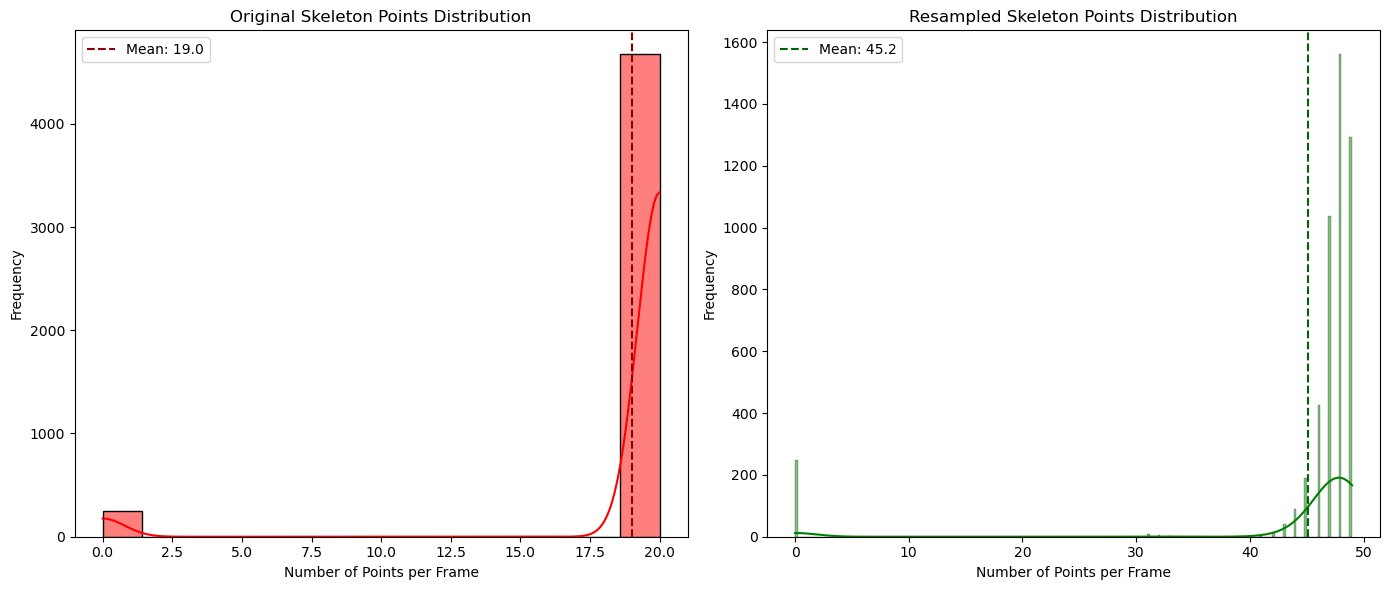

Original points per frame: min=0, max=20, mean=19.0, median=20.0
Resampled points per frame: min=0, max=49, mean=45.2, median=48.0

Standard deviation of point counts:
Original: 4.37
Resampled: 10.51
Resampling made point counts less consistent


In [9]:
# Count non-NaN points in each frame
original_points = skeleton_x.notna().sum(axis=1)
new_points = new_x_df.notna().sum(axis=1)

# Create figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot original points distribution
sns.histplot(original_points, kde=True, color='red', ax=ax1)
ax1.set_title('Original Skeleton Points Distribution')
ax1.set_xlabel('Number of Points per Frame')
ax1.set_ylabel('Frequency')
ax1.axvline(original_points.mean(), color='darkred', linestyle='--', 
           label=f'Mean: {original_points.mean():.1f}')
ax1.legend()

# Plot new points distribution
sns.histplot(new_points, kde=True, color='green', ax=ax2)
ax2.set_title('Resampled Skeleton Points Distribution')
ax2.set_xlabel('Number of Points per Frame')
ax2.set_ylabel('Frequency')
ax2.axvline(new_points.mean(), color='darkgreen', linestyle='--',
           label=f'Mean: {new_points.mean():.1f}')
ax2.legend()

plt.tight_layout()
plt.show()

# Print basic statistics
print(f"Original points per frame: min={original_points.min()}, max={original_points.max()}, "
      f"mean={original_points.mean():.1f}, median={original_points.median()}")
print(f"Resampled points per frame: min={new_points.min()}, max={new_points.max()}, "
      f"mean={new_points.mean():.1f}, median={new_points.median()}")

# Check if resampling created more consistent point counts
orig_std = original_points.std()
new_std = new_points.std()
print(f"\nStandard deviation of point counts:")
print(f"Original: {orig_std:.2f}")
print(f"Resampled: {new_std:.2f}")
print(f"Resampling made point counts {'more' if new_std < orig_std else 'less'} consistent")

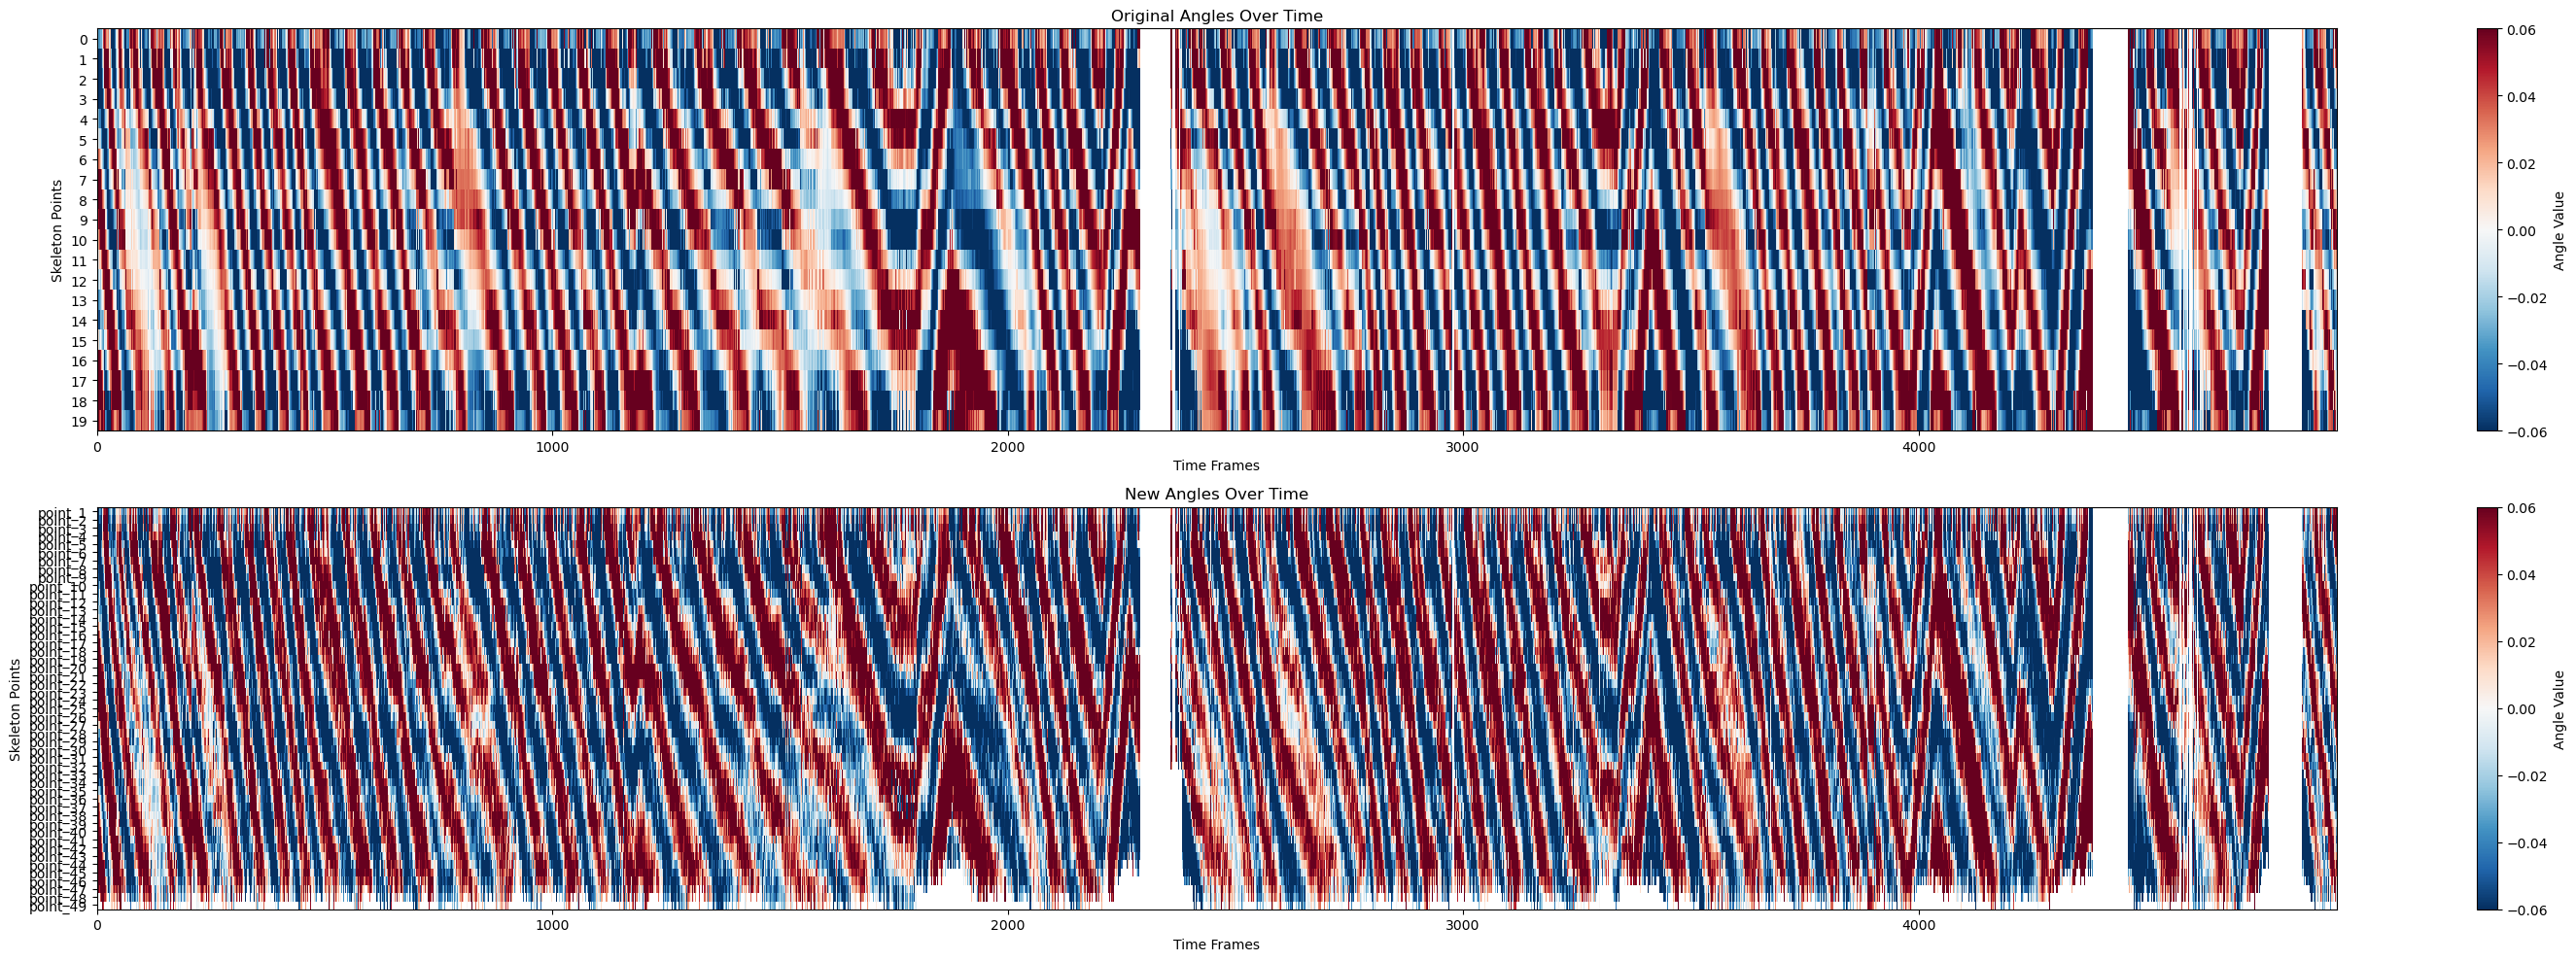


Statistics comparison:

Original angles:
Mean: 0.001519
Std: 0.065775
Min: -3.799000
Max: 1.544000
NaN count: 4940

New angles:
Mean: 0.002203
Std: 0.107858
Min: -7.272529
Max: 128.366885
NaN count: 18890


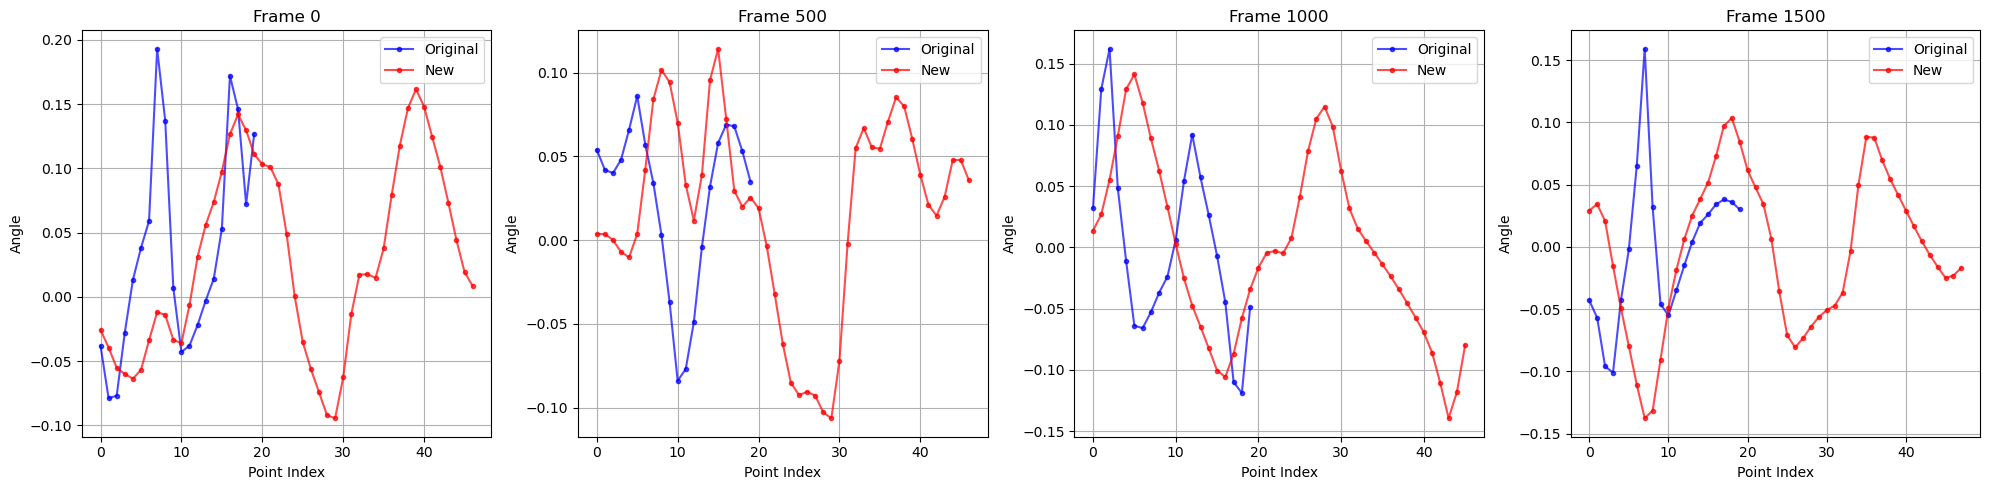

In [10]:
def plot_angle_comparison(old_angles, new_angles):
    """
    Plot old vs new angles in two subplots using heatmaps.
    
    Args:
        old_angles (pd.DataFrame): Original angle data
        new_angles (pd.DataFrame): New angle data
    """
    plt.figure(figsize=(30, 10))
    
    # Plot original angles
    plt.subplot(211)
    im1 = plt.imshow(old_angles.T,
                    aspect='auto',
                    cmap='RdBu_r',
                    interpolation='nearest',
                    vmin=-0.06,
                    vmax=0.06)
    
    plt.colorbar(im1, label='Angle Value')
    plt.title('Original Angles Over Time')
    plt.xlabel('Time Frames')
    plt.ylabel('Skeleton Points')
    plt.yticks(range(len(old_angles.columns)), old_angles.columns)
    
    # Plot new angles
    plt.subplot(212)
    im2 = plt.imshow(new_angles.T,
                    aspect='auto',
                    cmap='RdBu_r',
                    interpolation='nearest',
                    vmin=-0.06,
                    vmax=0.06)
    
    plt.colorbar(im2, label='Angle Value')
    plt.title('New Angles Over Time')
    plt.xlabel('Time Frames')
    plt.ylabel('Skeleton Points')
    plt.yticks(range(len(new_angles.columns)), new_angles.columns)
    
    plt.tight_layout()
    plt.show()
    
    # Print some statistics
    print("\nStatistics comparison:")
    print("\nOriginal angles:")
    print(f"Mean: {old_angles.mean().mean():.6f}")
    print(f"Std: {old_angles.std().mean():.6f}")
    print(f"Min: {old_angles.min().min():.6f}")
    print(f"Max: {old_angles.max().max():.6f}")
    print(f"NaN count: {old_angles.isna().sum().sum()}")
    
    print("\nNew angles:")
    print(f"Mean: {new_angles.mean().mean():.6f}")
    print(f"Std: {new_angles.std().mean():.6f}")
    print(f"Min: {new_angles.min().min():.6f}")
    print(f"Max: {new_angles.max().max():.6f}")
    print(f"NaN count: {new_angles.isna().sum().sum()}")

# Call the function with old and new angles
plot_angle_comparison(spline_K, spline_K_new)

# Additional visualization: Plot specific time points
def plot_specific_timepoints(old_angles, new_angles, timepoints=[0, 500, 1000, 1500]):
    """Plot angle values at specific timepoints for comparison"""
    plt.figure(figsize=(20, 5))
    
    for i, t in enumerate(timepoints):
        plt.subplot(1, len(timepoints), i+1)
        
        # Plot both old and new angles
        plt.plot(old_angles.iloc[t].values, 'b.-', label='Original', alpha=0.7)
        plt.plot(new_angles.iloc[t].values, 'r.-', label='New', alpha=0.7)
        
        plt.title(f'Frame {t}')
        plt.xlabel('Point Index')
        plt.ylabel('Angle')
        plt.grid(True)
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Call the timepoint comparison
plot_specific_timepoints(spline_K, spline_K_new)

Original Skeleton Statistics:
Mean distance: 4.94 ± 0.19
Median distance: 4.96
Min/Max: 3.17/6.39

New Skeleton Statistics:
Mean distance: 2.00 ± 0.00
Median distance: 2.00
Min/Max: 1.96/2.00


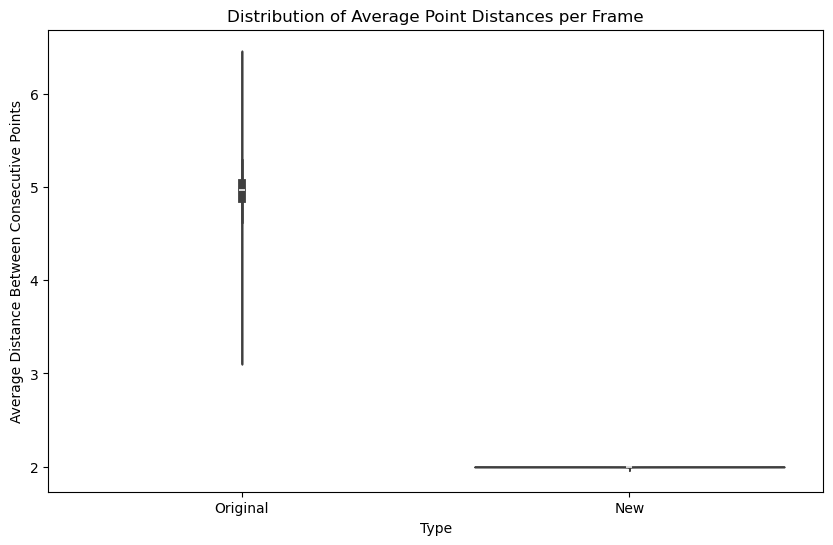

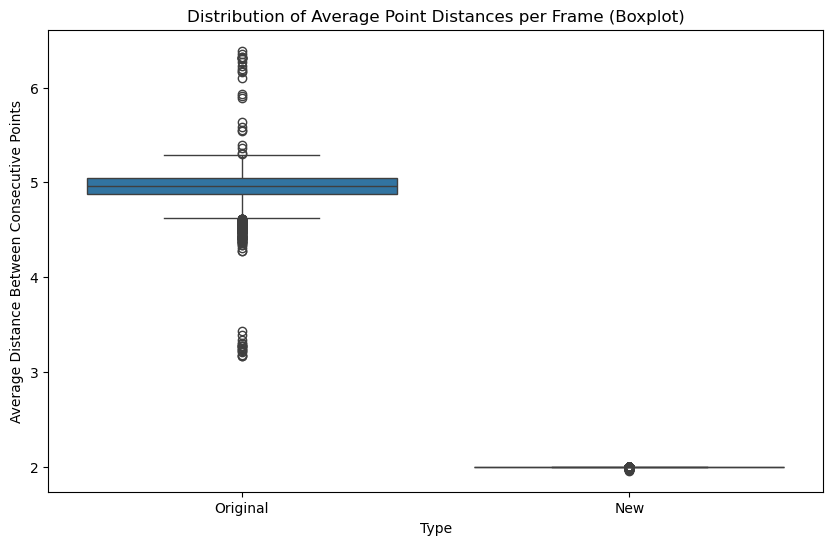

In [11]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.spatial.distance import euclidean

def calculate_frame_distances(x_df, y_df):
    """
    Calculate average distance between consecutive points for each frame.
    
    Args:
        x_df: DataFrame with x coordinates
        y_df: DataFrame with y coordinates
    Returns:
        List of average distances per frame
    """
    frame_distances = []
    
    for frame in range(len(x_df)):
        # Get non-NaN points for this frame
        x_coords = x_df.iloc[frame].dropna()
        y_coords = y_df.iloc[frame].dropna()
        
        if len(x_coords) < 2:  # Need at least 2 points
            continue
            
        # Calculate distances between consecutive points
        distances = []
        for i in range(len(x_coords)-1):
            dist = euclidean(
                [x_coords.iloc[i], y_coords.iloc[i]],
                [x_coords.iloc[i+1], y_coords.iloc[i+1]]
            )
            distances.append(dist)
            
        # Store average distance for this frame
        if distances:
            frame_distances.append(np.mean(distances))
    
    return frame_distances

# Calculate distances for both skeletons
old_distances = calculate_frame_distances(skeleton_x, skeleton_y)
new_distances = calculate_frame_distances(new_x_df, new_y_df)

# Create DataFrame for plotting
plot_data = pd.DataFrame({
    'Distances': old_distances + new_distances,
    'Type': ['Original']*len(old_distances) + ['New']*len(new_distances)
})

# Create violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(data=plot_data, x='Type', y='Distances')
plt.title('Distribution of Average Point Distances per Frame')
plt.ylabel('Average Distance Between Consecutive Points')

# Add statistical information
print("Original Skeleton Statistics:")
print(f"Mean distance: {np.mean(old_distances):.2f} ± {np.std(old_distances):.2f}")
print(f"Median distance: {np.median(old_distances):.2f}")
print(f"Min/Max: {np.min(old_distances):.2f}/{np.max(old_distances):.2f}")
print(f"\nNew Skeleton Statistics:")
print(f"Mean distance: {np.mean(new_distances):.2f} ± {np.std(new_distances):.2f}")
print(f"Median distance: {np.median(new_distances):.2f}")
print(f"Min/Max: {np.min(new_distances):.2f}/{np.max(new_distances):.2f}")

plt.show()

# Optional: Add boxplot for another view of the distribution
plt.figure(figsize=(10, 6))
sns.boxplot(data=plot_data, x='Type', y='Distances')
plt.title('Distribution of Average Point Distances per Frame (Boxplot)')
plt.ylabel('Average Distance Between Consecutive Points')
plt.show()

In [12]:
# ===== SMOOTHING FUNCTIONS =====
import numpy as np
import pandas as pd
from scipy.ndimage import gaussian_filter

def smooth_2d_data(data, time_sigma=1, spatial_sigma=1):
    """
    Smooth 2D data using Gaussian filtering while preserving NaN values
    and maintaining boundary information
    
    Args:
        data (pd.DataFrame): Input data frame
        time_sigma (float): Standard deviation for time-axis smoothing
        spatial_sigma (float): Standard deviation for spatial-axis smoothing
    
    Returns:
        pd.DataFrame: Smoothed data with same structure as input
    """
    # Convert to numpy array for smoothing
    values = data.values
    
    # Create a mask for NaN values
    nan_mask = np.isnan(values)
    
    # Replace NaNs with zeros for filtering
    filled_values = np.nan_to_num(values, nan=0.0)
    
    # Apply 2D Gaussian smoothing
    smoothed = gaussian_filter(filled_values, sigma=[time_sigma, spatial_sigma], mode='nearest')
    
    # Create a weight array (1 for data, 0 for NaN)
    weights = ~nan_mask
    weight_smoothed = gaussian_filter(weights.astype(float), sigma=[time_sigma, spatial_sigma], mode='nearest')
    
    # Avoid division by zero
    weight_smoothed[weight_smoothed < 1e-10] = 1
    
    # Normalize the result
    result = smoothed / weight_smoothed
    
    # Restore NaN values where they were before
    result[nan_mask] = np.nan
    
    # Convert back to DataFrame with same structure
    return pd.DataFrame(result, index=data.index, columns=data.columns)

smoothed_spline_K = smooth_2d_data(spline_K_new, time_sigma=time_sigma, spatial_sigma=spatial_sigma)

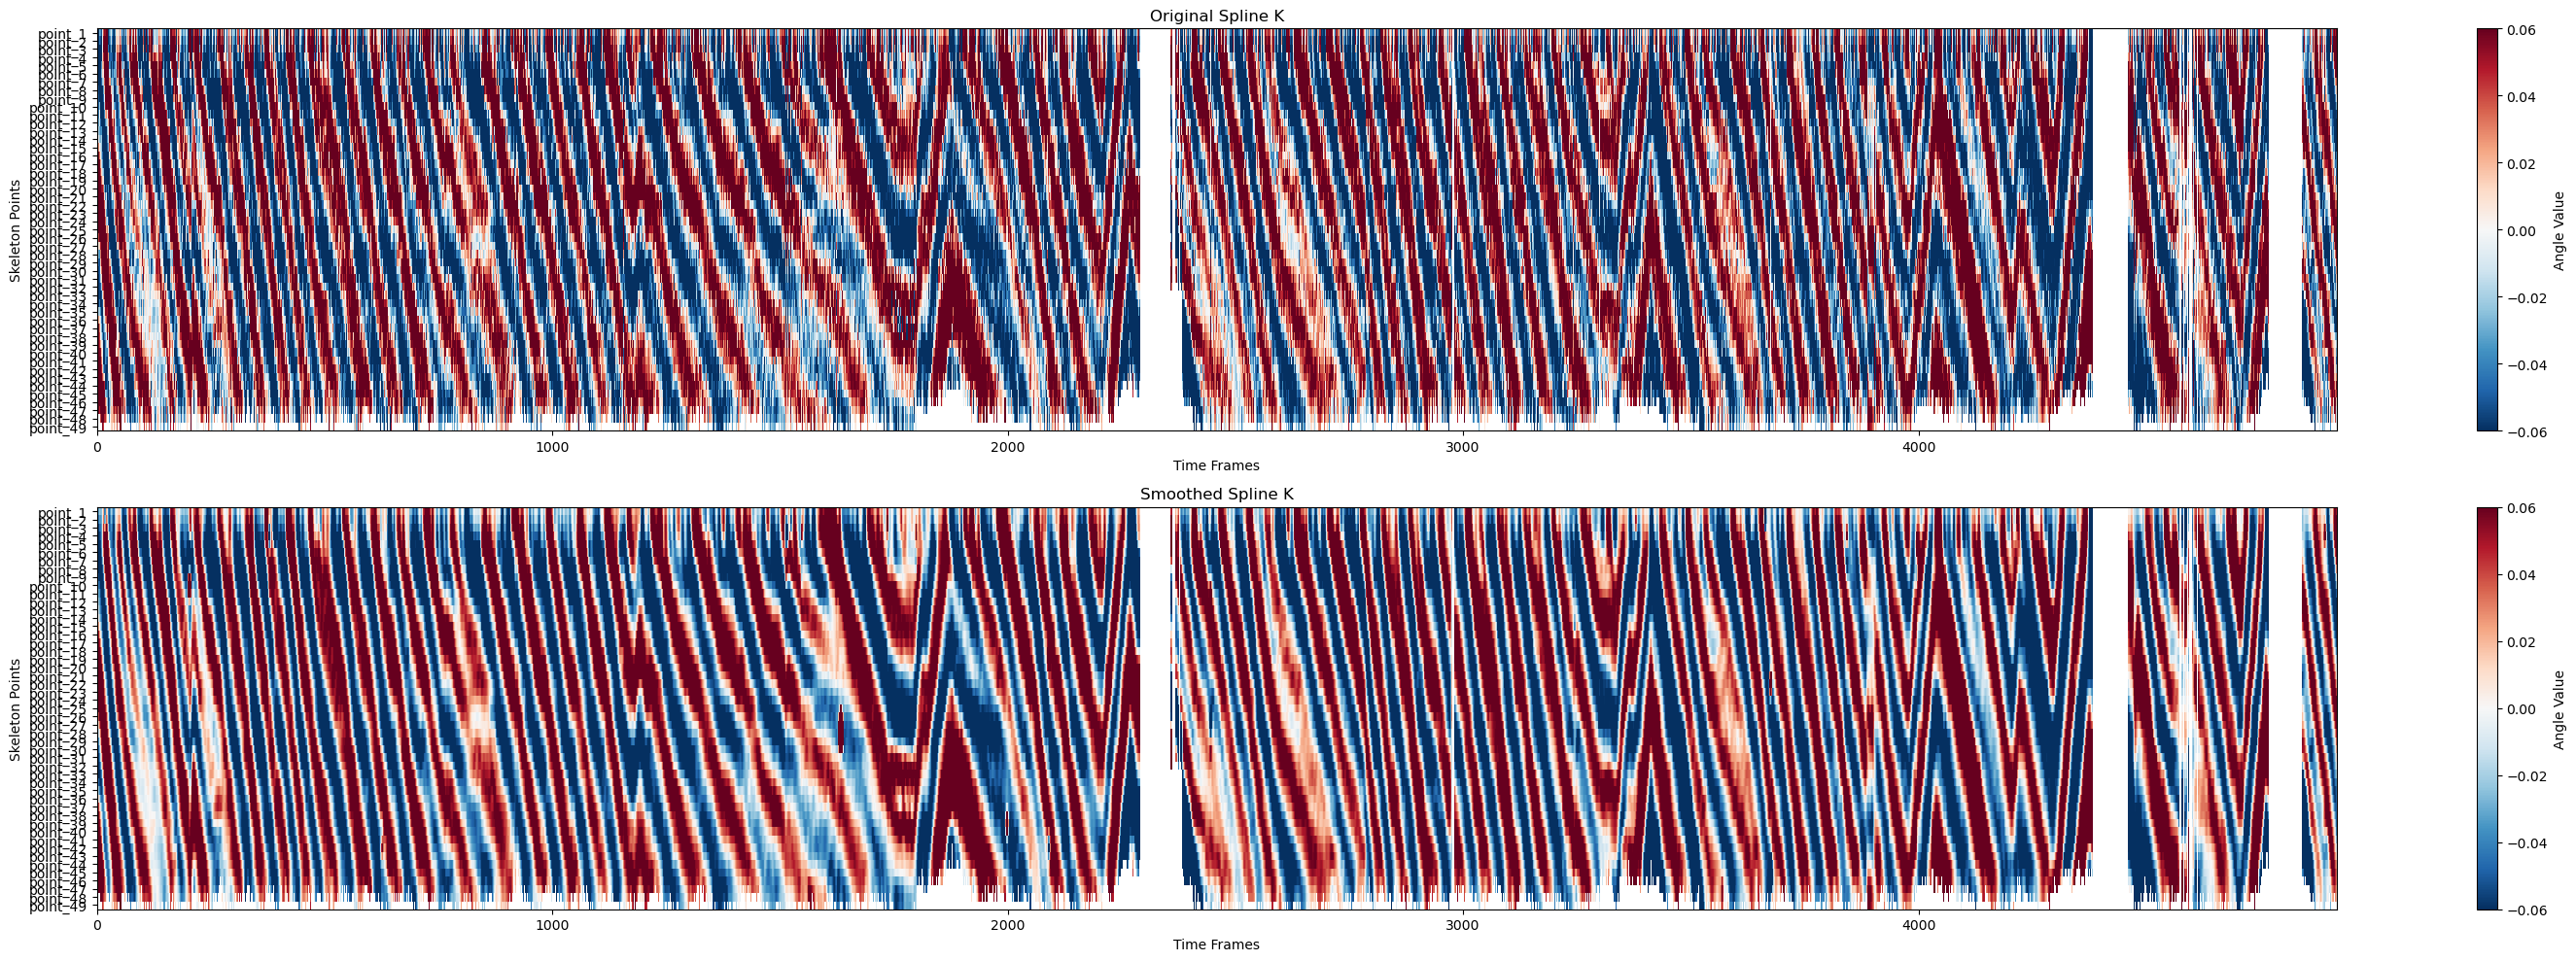


Statistics comparison:

Original data:
Mean: 0.002203
Std: 0.107858
Min: -7.272529
Max: 128.366885

Smoothed data:
Mean: 0.002205
Std: 0.066889
Min: -0.635842
Max: 10.143382


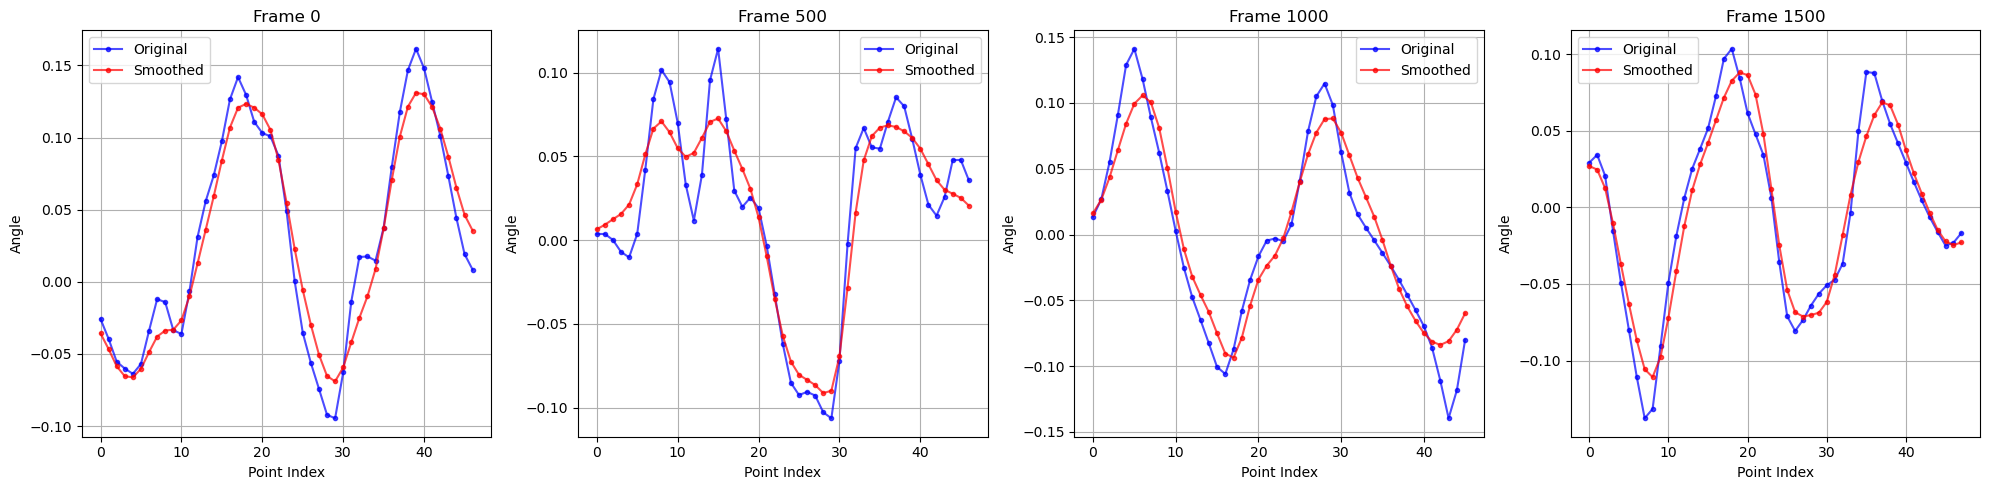

In [13]:
# ===== VISUALIZATION FUNCTIONS =====
import matplotlib.pyplot as plt

def plot_spline_comparison(original_data, smoothed_data):
    """
    Plot original vs smoothed spline data using heatmaps
    
    Args:
        original_data (pd.DataFrame): Original spline data
        smoothed_data (pd.DataFrame): Smoothed spline data
    """
    plt.figure(figsize=(30, 10))
    
    # Plot original data
    plt.subplot(211)
    im1 = plt.imshow(original_data.T,
                    aspect='auto',
                    cmap='RdBu_r',
                    interpolation='nearest',
                    vmin=-0.06,
                    vmax=0.06)
    
    plt.colorbar(im1, label='Angle Value')
    plt.title('Original Spline K')
    plt.xlabel('Time Frames')
    plt.ylabel('Skeleton Points')
    plt.yticks(range(len(original_data.columns)), original_data.columns)
    
    # Plot smoothed data
    plt.subplot(212)
    im2 = plt.imshow(smoothed_data.T,
                    aspect='auto',
                    cmap='RdBu_r',
                    interpolation='nearest',
                    vmin=-0.06,
                    vmax=0.06)
    
    plt.colorbar(im2, label='Angle Value')
    plt.title('Smoothed Spline K')
    plt.xlabel('Time Frames')
    plt.ylabel('Skeleton Points')
    plt.yticks(range(len(smoothed_data.columns)), smoothed_data.columns)
    
    plt.tight_layout()
    plt.show()
    
    # Print statistics
    print("\nStatistics comparison:")
    print("\nOriginal data:")
    print(f"Mean: {original_data.mean().mean():.6f}")
    print(f"Std: {original_data.std().mean():.6f}")
    print(f"Min: {original_data.min().min():.6f}")
    print(f"Max: {original_data.max().max():.6f}")
    
    print("\nSmoothed data:")
    print(f"Mean: {smoothed_data.mean().mean():.6f}")
    print(f"Std: {smoothed_data.std().mean():.6f}")
    print(f"Min: {smoothed_data.min().min():.6f}")
    print(f"Max: {smoothed_data.max().max():.6f}")

def plot_specific_timepoints(original_data, smoothed_data, timepoints=[0, 500, 1000, 1500]):
    """
    Plot angle values at specific timepoints for comparison
    
    Args:
        original_data (pd.DataFrame): Original spline data
        smoothed_data (pd.DataFrame): Smoothed spline data
        timepoints (list): List of time points to plot
    """
    plt.figure(figsize=(20, 5))
    
    for i, t in enumerate(timepoints):
        plt.subplot(1, len(timepoints), i+1)
        
        # Plot both original and smoothed data
        plt.plot(original_data.iloc[t].values, 'b.-', label='Original', alpha=0.7)
        plt.plot(smoothed_data.iloc[t].values, 'r.-', label='Smoothed', alpha=0.7)
        
        plt.title(f'Frame {t}')
        plt.xlabel('Point Index')
        plt.ylabel('Angle')
        plt.grid(True)
        plt.legend()
    
    plt.tight_layout()
    plt.show()

# Generate visualizations
plot_spline_comparison(spline_K_new, smoothed_spline_K)
plot_specific_timepoints(spline_K_new, smoothed_spline_K)

Original column count: 49
Columns to keep: 48
Columns to remove: 1
Occupancy at cutoff: 58.0% → 26.3%
Rate of change at cutoff: -54.7%


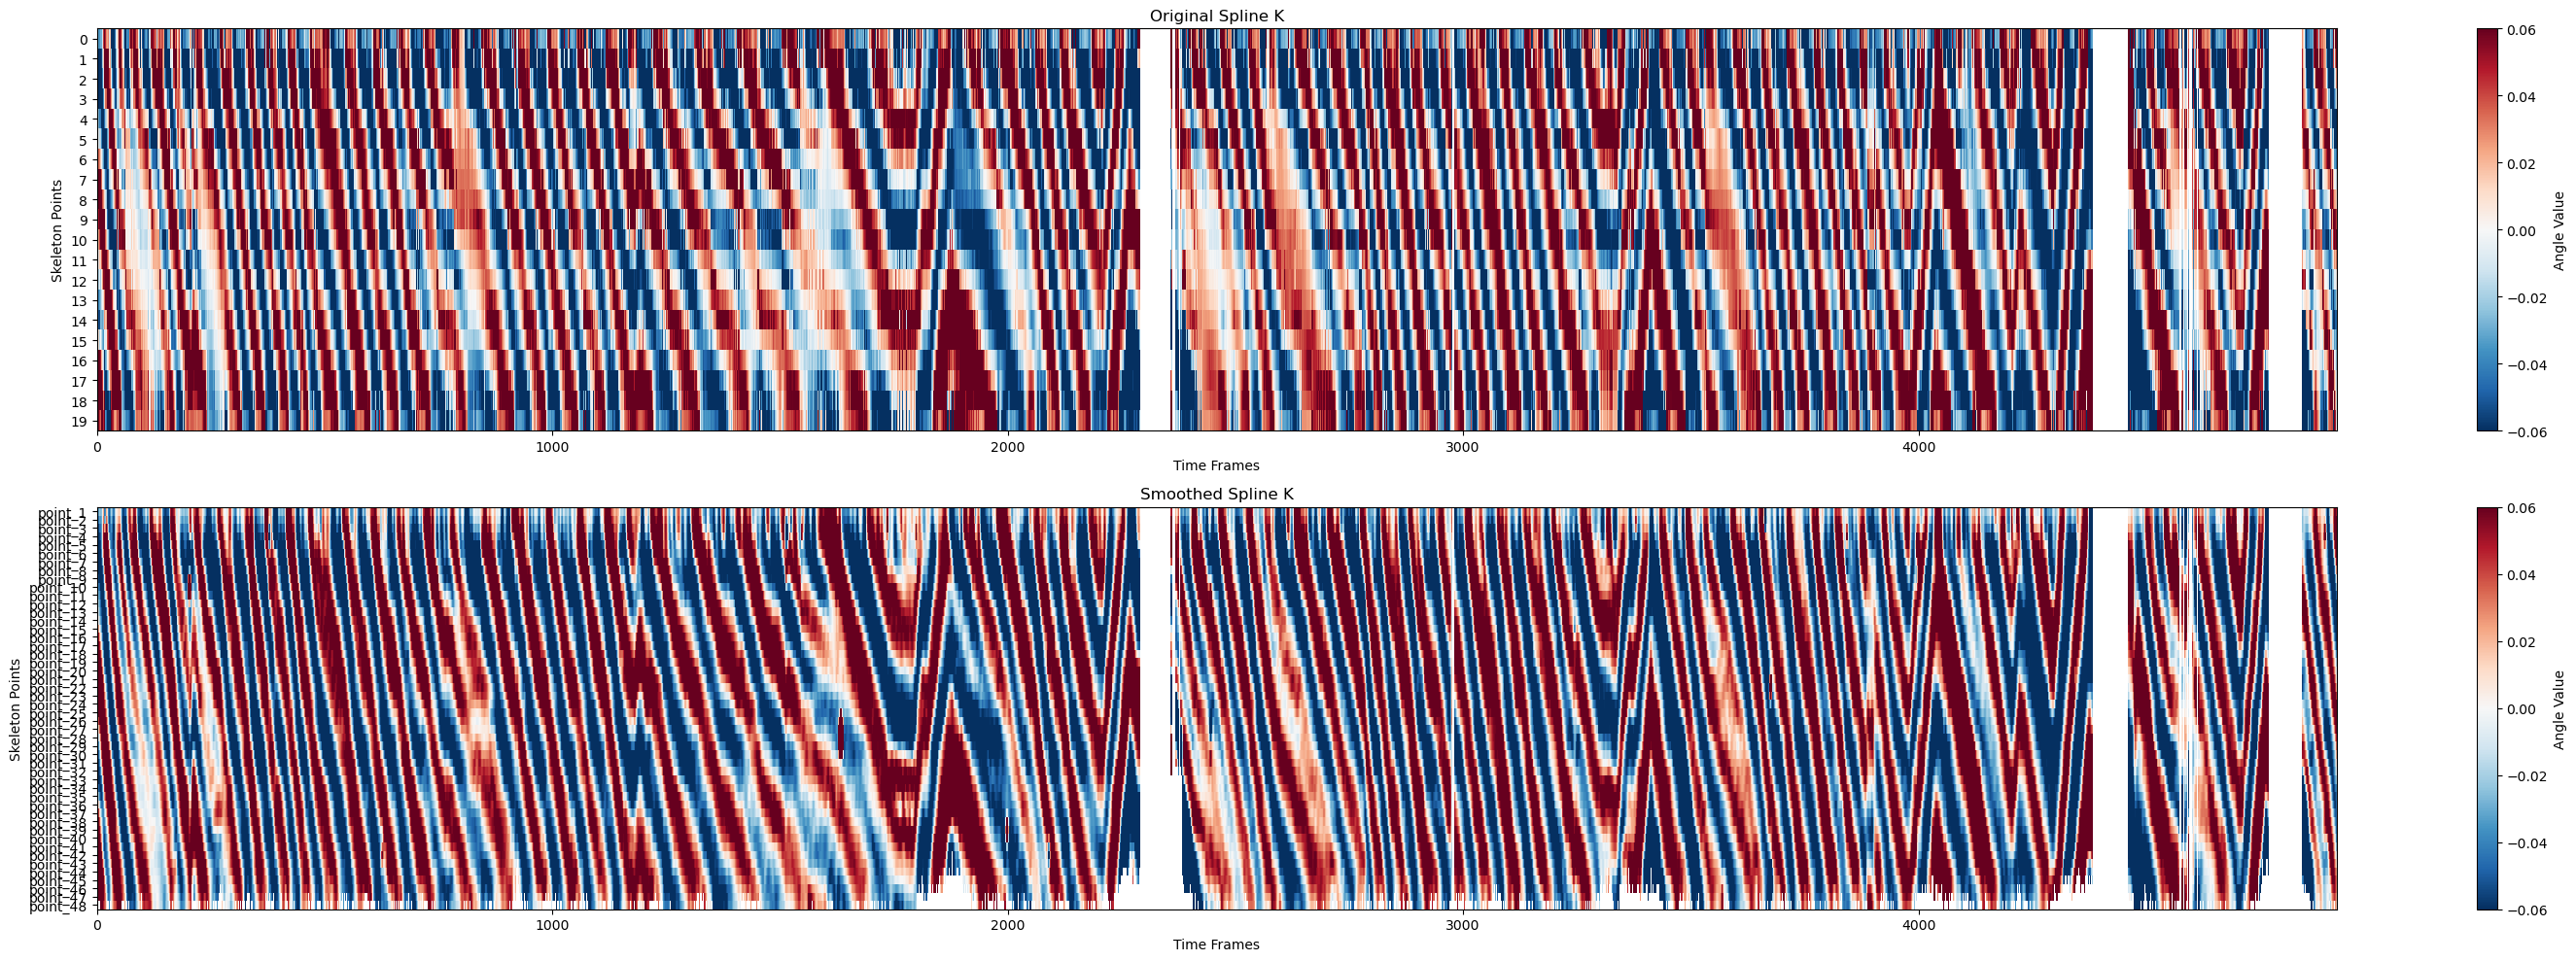


Statistics comparison:

Original data:
Mean: 0.001519
Std: 0.065775
Min: -3.799000
Max: 1.544000

Smoothed data:
Mean: 0.002414
Std: 0.067616
Min: -0.635808
Max: 10.143382


In [17]:
def find_optimal_column_crop(df, change_threshold=0.25, min_columns=10):
    """
    Find optimal column crop point by detecting significant drops in occupancy rate.
    
    Args:
        df: pandas DataFrame to analyze
        change_threshold: rate of change threshold to identify significant drops (0-1)
        min_columns: minimum number of columns to keep regardless of occupancy
    
    Returns:
        list: column indices to keep
    """
    import numpy as np
    
    # Calculate column occupancy (non-NaN percentage)
    col_occupancy = df.notna().mean(axis=0) * 100
    
    # Calculate rate of change between adjacent columns
    occupancy_changes = np.zeros(len(col_occupancy))
    for i in range(1, len(col_occupancy)):
        if col_occupancy.iloc[i-1] > 0:  # Avoid division by zero
            relative_change = (col_occupancy.iloc[i] - col_occupancy.iloc[i-1]) / col_occupancy.iloc[i-1]
            occupancy_changes[i] = relative_change
    
    # Find points with significant negative changes (drops)
    col_drops = []
    for i in range(1, len(occupancy_changes)):
        if occupancy_changes[i] < -change_threshold and i >= min_columns:
            col_drops.append(i)
    
    # If no clear drop is found, keep all columns
    if not col_drops:
        cols_to_keep = df.columns
    else:
        # Keep columns up to the first significant drop
        cols_to_keep = df.columns[:col_drops[0]]
    
    # Print statistics for information
    print(f"Original column count: {df.shape[1]}")
    print(f"Columns to keep: {len(cols_to_keep)}")
    print(f"Columns to remove: {df.shape[1] - len(cols_to_keep)}")
    
    # Print occupancy at cutoff point if applicable
    if col_drops:
        cutoff_idx = col_drops[0]
        print(f"Occupancy at cutoff: {col_occupancy.iloc[cutoff_idx-1]:.1f}% → {col_occupancy.iloc[cutoff_idx]:.1f}%")
        print(f"Rate of change at cutoff: {occupancy_changes[cutoff_idx]:.1%}")
    
    return cols_to_keep

# Usage:
cols_to_keep = find_optimal_column_crop(spline_K_new, change_threshold=0.50, min_columns=10)
cropped_spline_K = spline_K_new[cols_to_keep]
# Then apply smoothing to the column-cropped data
smoothed_cropped_K = smooth_2d_data(cropped_spline_K, time_sigma=time_sigma, spatial_sigma=spatial_sigma)
# Visualize with the cropped data
plot_spline_comparison(spline_K, smoothed_cropped_K)